In [14]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import colorcet as cc

In [2]:
bl_dataset = xr.load_dataset("/home/leoseen/aos_773/final_project/blh_era5.grib", engine = 'cfgrib')
fv_dataset = xr.load_dataset("/home/leoseen/aos_773/final_project/friction_velocity_era5.grib", engine = 'cfgrib')
fv_data = fv_dataset.sel(latitude = '-90', longitude = '-180.0')
fv_daily_data = fv_data.groupby('time.date')
bl_data = bl_dataset.sel(latitude = '-90', longitude = '-180.0')
bl_daily_data = bl_data.groupby('time.date')

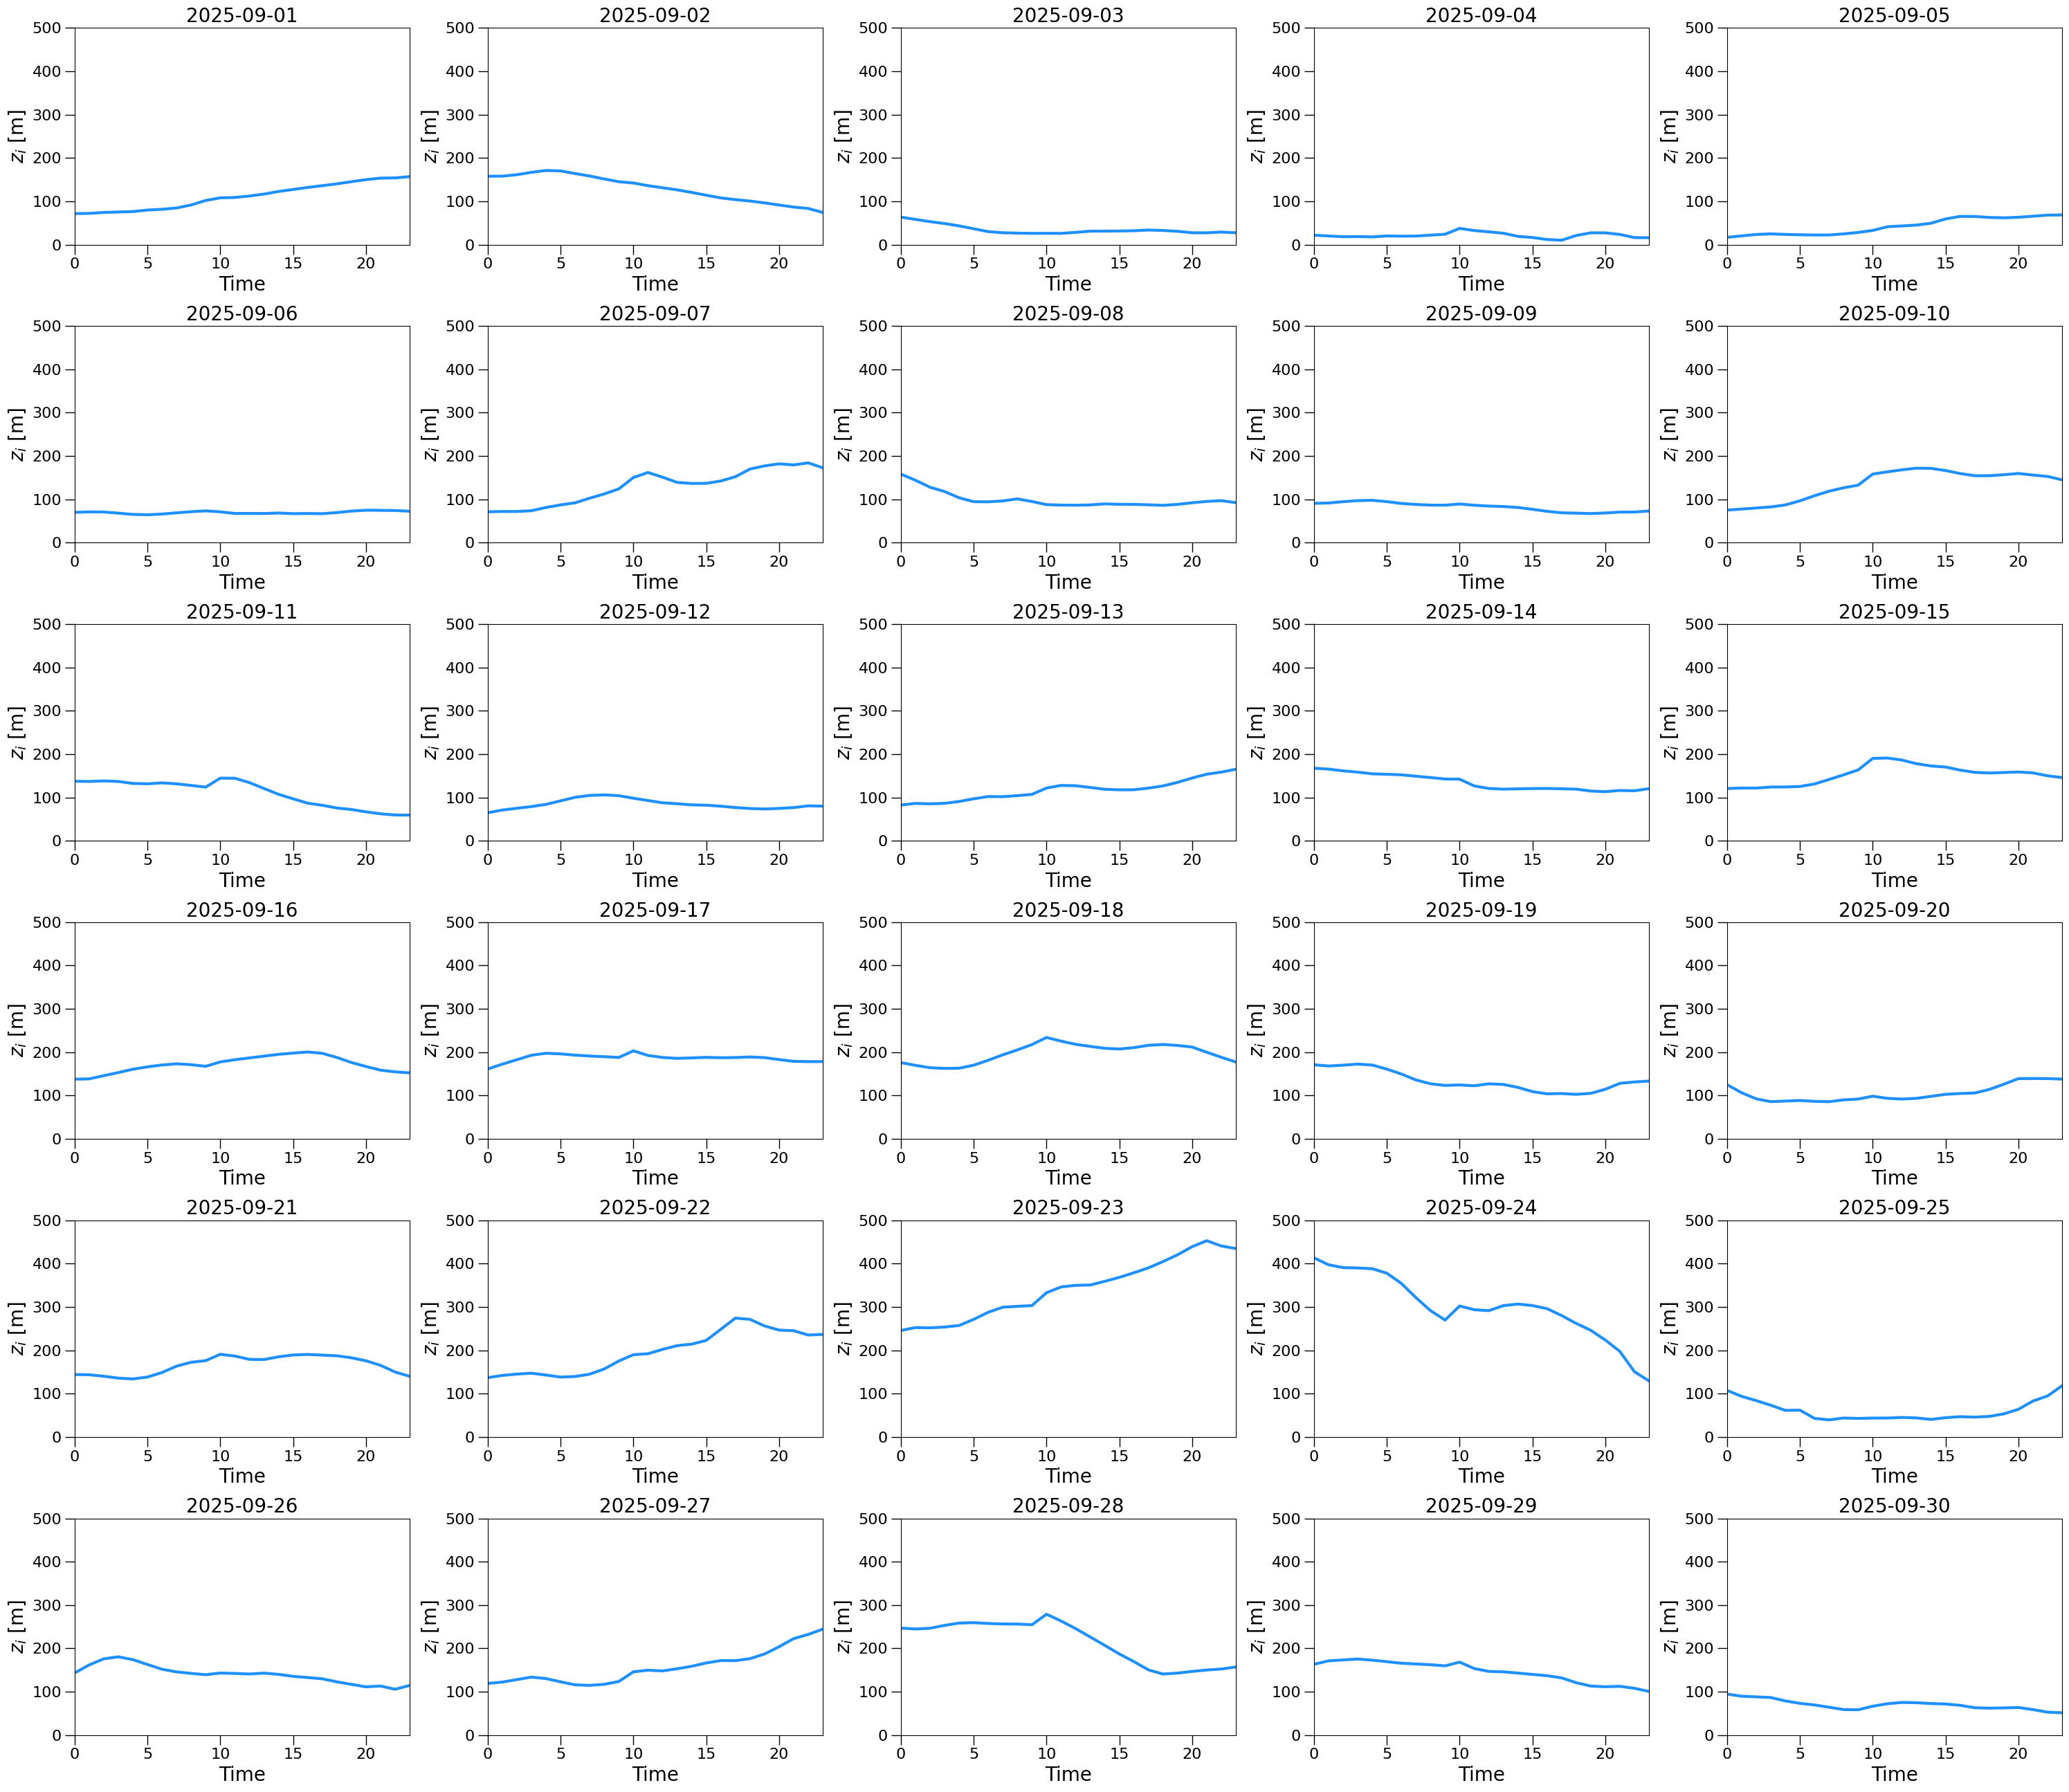

In [3]:
fig, axs = plt.subplots(6,5, figsize = (30,26))
i, j = 0, 0
for day, data in bl_daily_data:
    cm = axs[j][i].plot(data.time.values.astype('datetime64[h]').astype(int)%24, data.blh.values, linewidth = 3, color = 'dodgerblue')
    axs[j][i].set_ylim(0,500)
    axs[j][i].set_xlim(0,23)
    axs[j][i].set_xlabel(f'Time', fontsize = 20)
    axs[j][i].set_ylabel(r'$z_i$ [m]', fontsize = 20)
    axs[j][i].tick_params(axis = 'both', which = 'major', labelsize = 16, width = 1, length = 10)
    axs[j][i].tick_params(axis = 'both', which = 'minor', labelsize = 16, width = 1, length = 4)
    axs[j][i].set_title(day, fontsize = 20)
    i+=1
    if i%5 == 0:
        i = 0
        j += 1
fig.tight_layout()

Text(0.5, 1.0, 'September 2025')

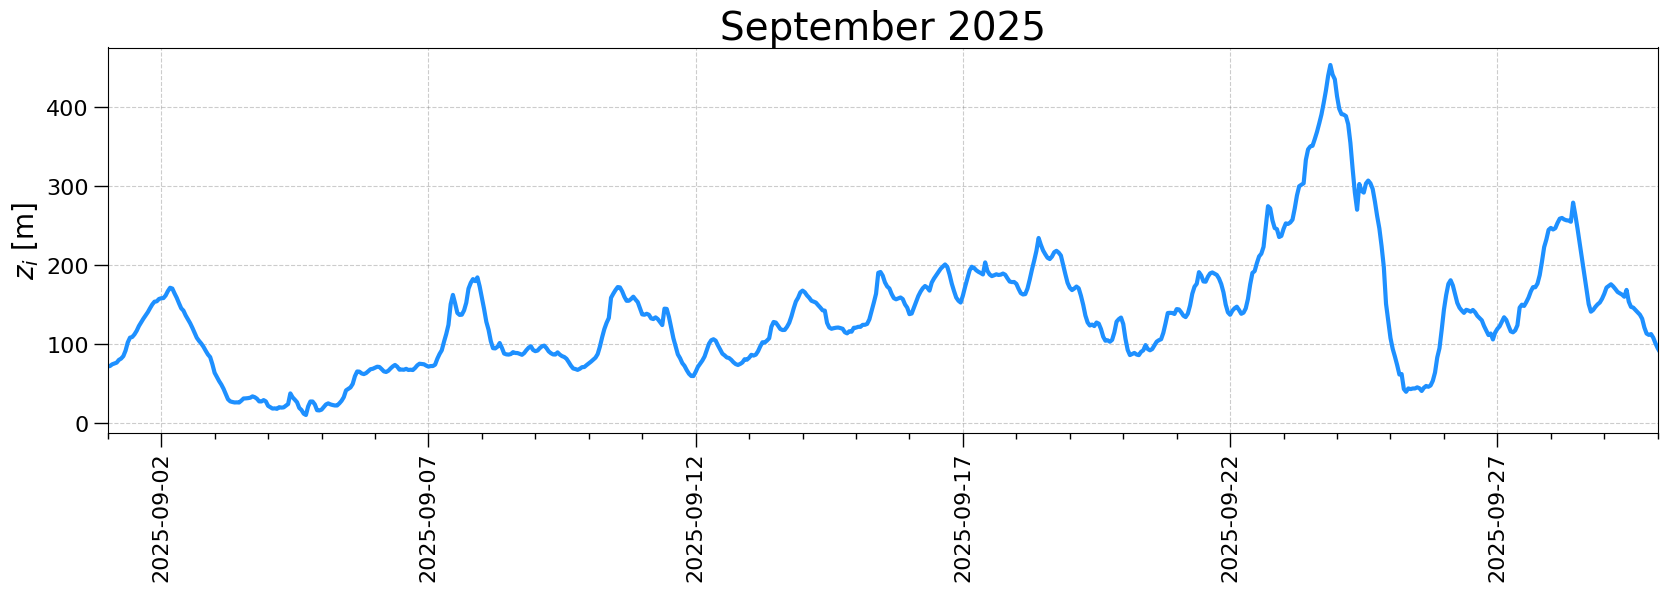

In [33]:
fig, axs = plt.subplots(1,1, figsize = (20,5))
axs.plot(bl_data.time, bl_data.blh.values, linewidth = 3, color = 'dodgerblue')
# axs.set_ylim(0,0.5)
axs.set_xlim(np.datetime64('2025-09-01'),np.datetime64('2025-09-30'))
axs.set_ylabel(r'$z_i$ [m]', fontsize = 20)
axs.tick_params(axis = 'both', which = 'major', labelsize = 16, width = 1, length = 10)
axs.tick_params(axis = 'both', which = 'minor', labelsize = 16, width = 1, length = 4)
axs.tick_params(axis = 'x', labelrotation = 90)
axs.xaxis.set_major_locator(mdates.DayLocator(interval=5))   
axs.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
axs.xaxis.set_minor_locator(mdates.DayLocator(interval=1))

axs.grid(alpha = 0.4, color = 'grey', linestyle = '--')
axs.set_title('September 2025', fontsize = 28)

In [4]:
times = []
fv_concat_data = np.concatenate(fv_data.zust.values)
for time in fv_data.time:
    times.append(time.values+(fv_data.step.values/np.timedelta64(1, 'h')).astype('timedelta64[h]'))
times = np.concatenate(times)
adjusted_fv_data = pd.DataFrame({'times':times, 'fv':fv_concat_data})
adjusted_fv_daily_data = adjusted_fv_data.groupby(adjusted_fv_data['times'].dt.date)

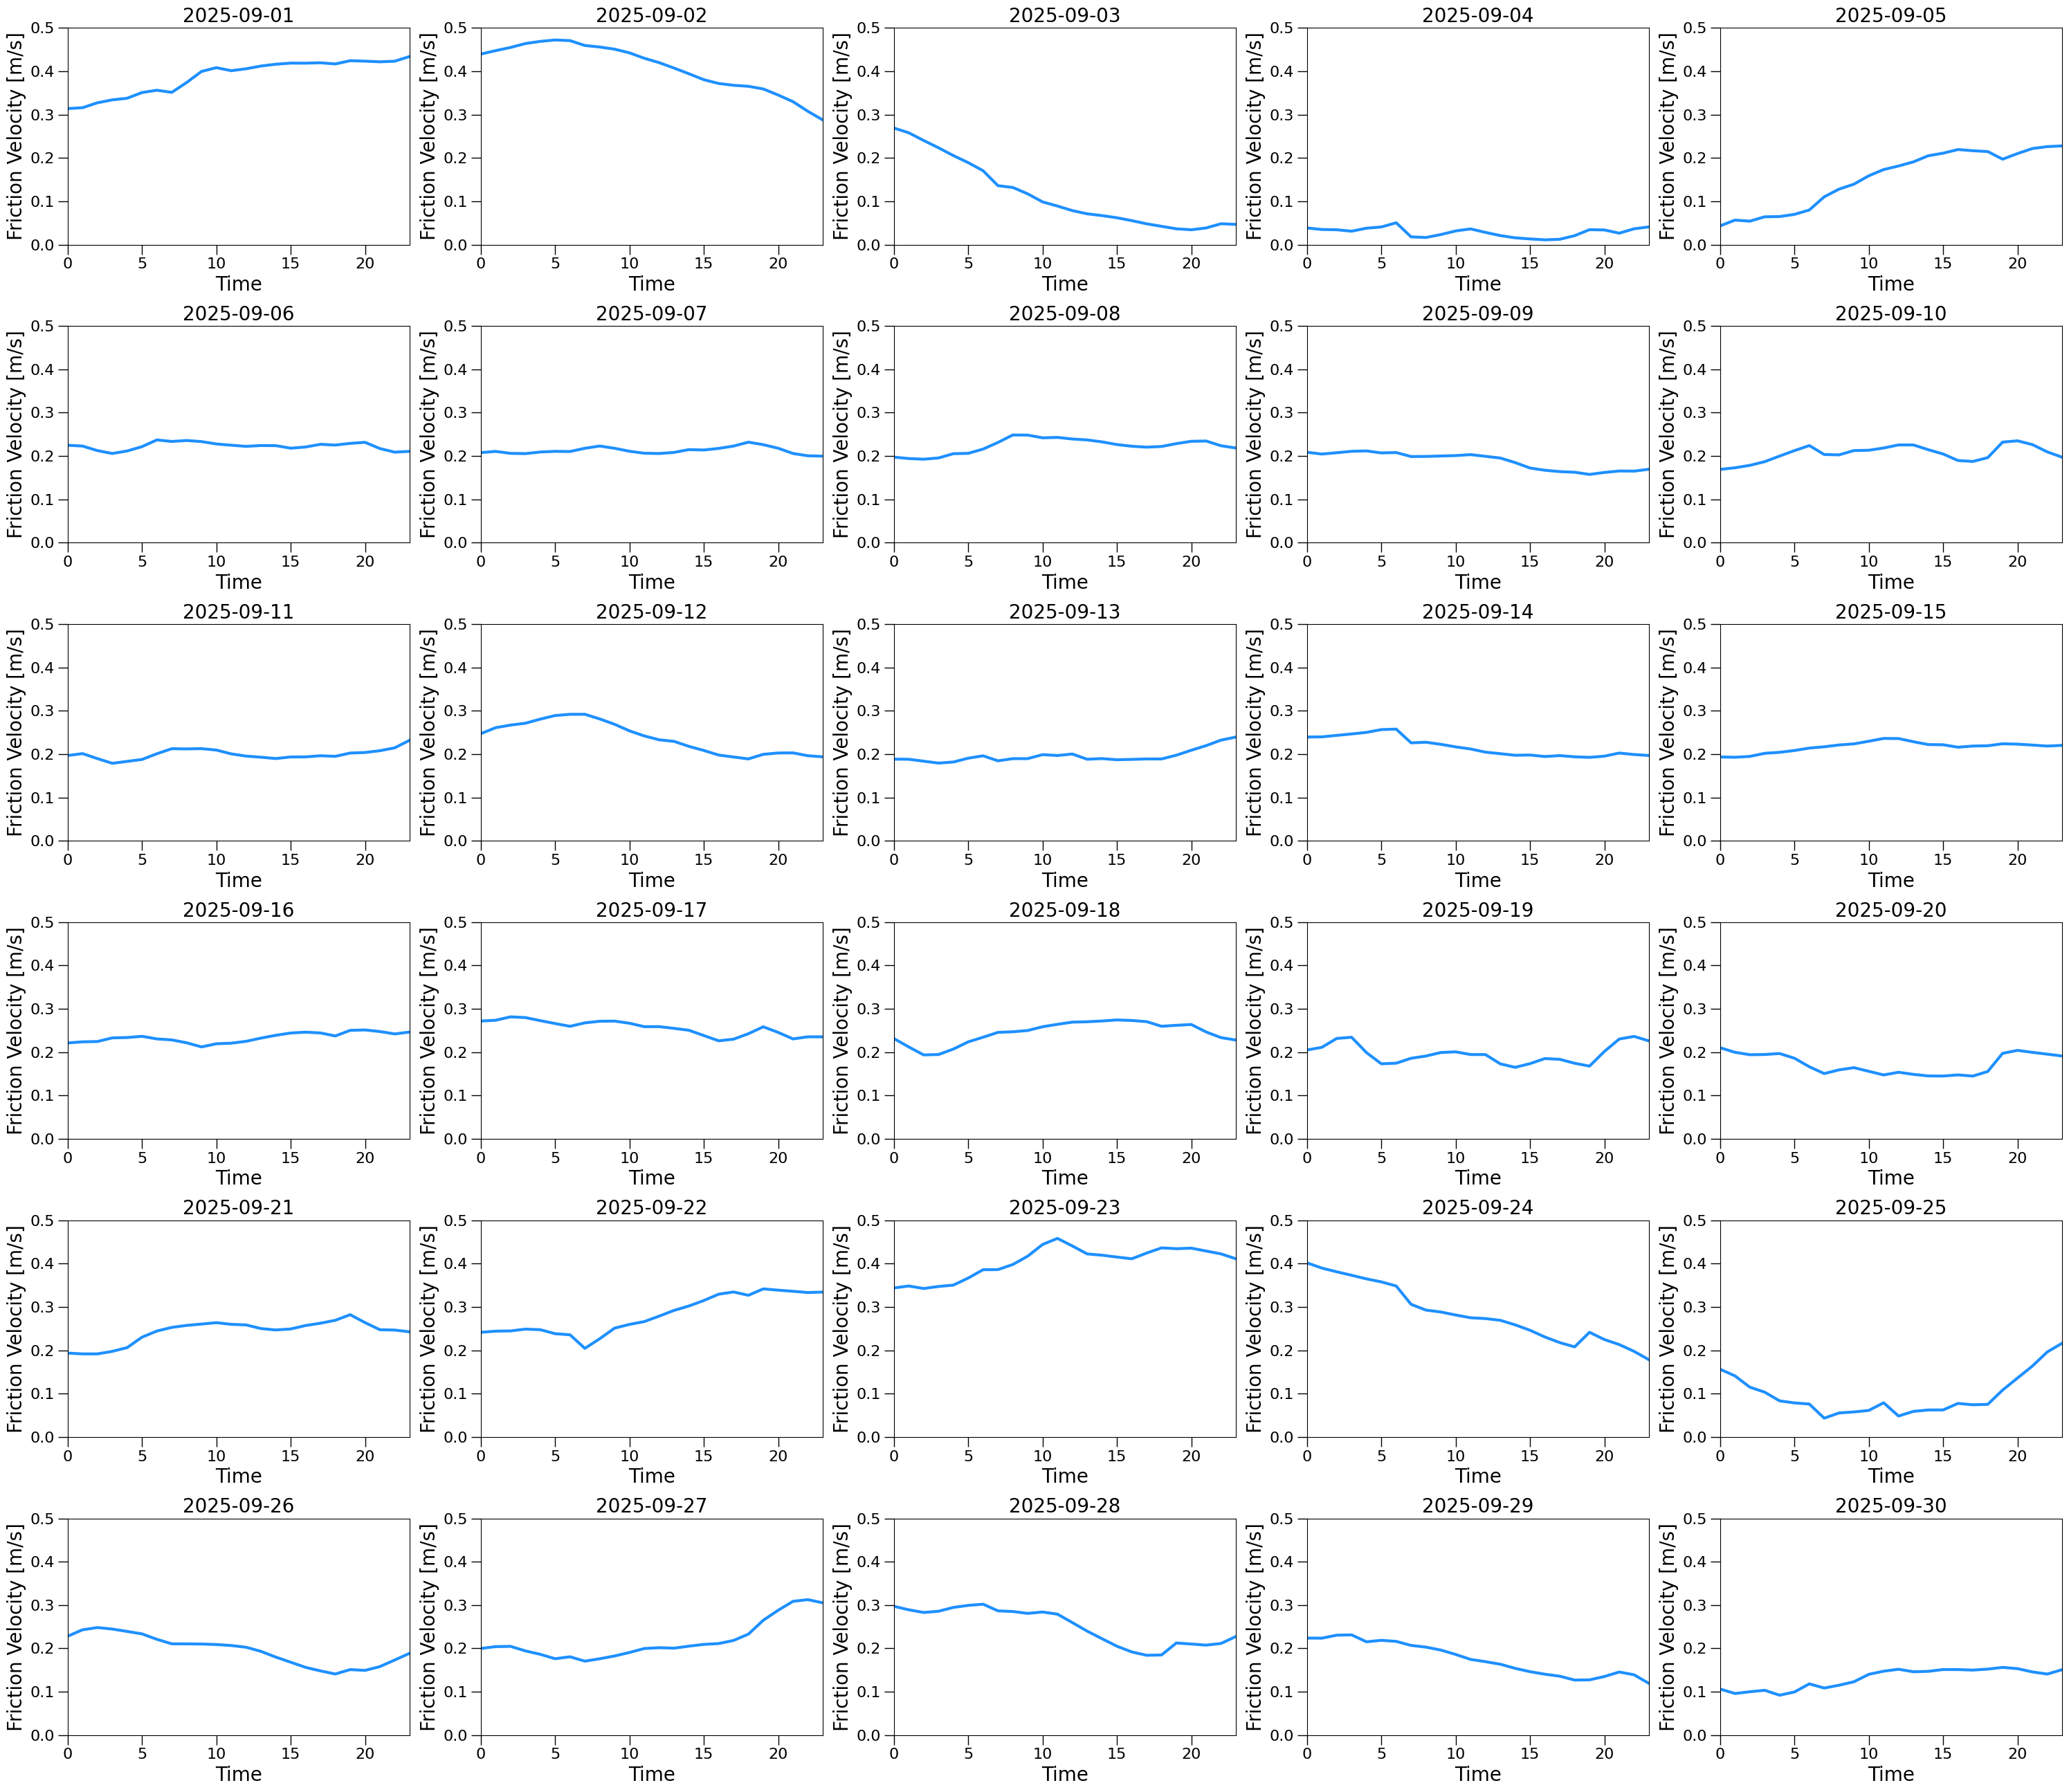

In [5]:
fig, axs = plt.subplots(6,5, figsize = (30,26))
i, j = 0, 0
for day, data in adjusted_fv_daily_data:
    if day.month == 8 or day.month == 10:
        continue
    cm = axs[j][i].plot(data['times'].dt.hour, data['fv'], linewidth = 3, color = 'dodgerblue')
    axs[j][i].set_ylim(0,0.5)
    axs[j][i].set_xlim(0,23)
    axs[j][i].set_xlabel(f'Time', fontsize = 20)
    axs[j][i].set_ylabel(r'Friction Velocity [m/s]', fontsize = 20)
    axs[j][i].tick_params(axis = 'both', which = 'major', labelsize = 16, width = 1, length = 10)
    axs[j][i].tick_params(axis = 'both', which = 'minor', labelsize = 16, width = 1, length = 4)
    axs[j][i].set_title(day, fontsize = 20)
    i+=1
    if i%5 == 0:
        i = 0
        j += 1
fig.tight_layout()

Text(0.5, 1.0, 'September 2025')

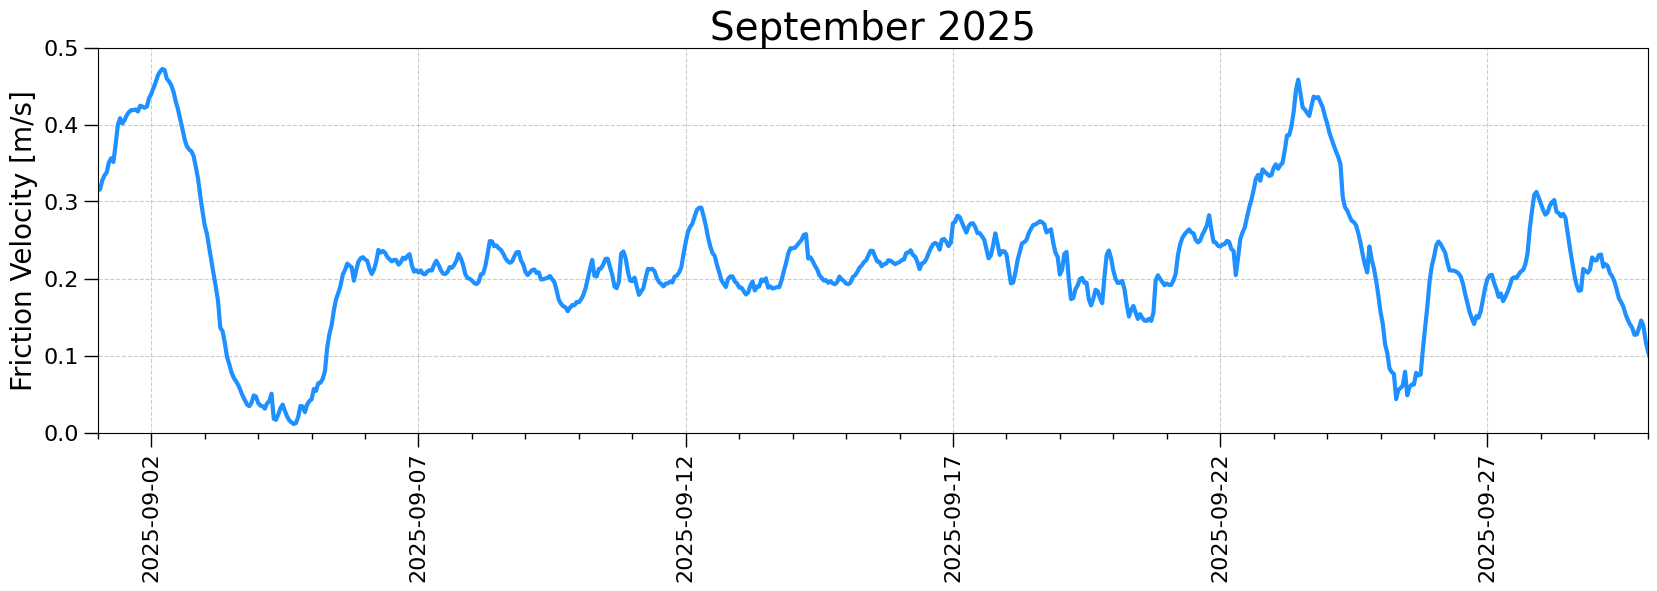

In [29]:
fig, axs = plt.subplots(1,1, figsize = (20,5))
axs.plot(adjusted_fv_data['times'], adjusted_fv_data['fv'], linewidth = 3, color = 'dodgerblue')
axs.set_ylim(0,0.5)
axs.set_xlim(np.datetime64('2025-09-01'),np.datetime64('2025-09-30'))
axs.set_ylabel(r'Friction Velocity [m/s]', fontsize = 20)
axs.tick_params(axis = 'both', which = 'major', labelsize = 16, width = 1, length = 10)
axs.tick_params(axis = 'both', which = 'minor', labelsize = 16, width = 1, length = 4)
axs.tick_params(axis = 'x', labelrotation = 90)
axs.xaxis.set_major_locator(mdates.DayLocator(interval=5))   
axs.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
axs.xaxis.set_minor_locator(mdates.DayLocator(interval=1))

axs.grid(alpha = 0.4, color = 'grey', linestyle = '--')
axs.set_title('September 2025', fontsize = 28)